# HS4002 Week 3

## Data Preparation

This week we need the `scipy` library for skewness and kurtosis statistics.

Make sure `gss2022_mini.csv` is in the same folder.

In [1]:
# !pip install pandas numpy scipy plotnine

import pandas as pd
import numpy as np
import plotnine as p9
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import skew, kurtosis

## Select variables of interest

In [31]:
raw_df = pd.read_csv("gss2022_mini.csv")

chosen_variables = [
"id", "yrlvmus", "yrartxbt", "yrmovie", "yrcreat", "income16", "prestg10", "educ"]
	
df = raw_df[chosen_variables].copy()

## Remove all rows with missing values

In [32]:
df = df.dropna()

## Recode categorical variables into binary variables

`1 = attended / participated`, `0 = did not`. Refer to the GSS Codebook for coding.

In [33]:
df['binary_lvmus']  = np.where(df['yrlvmus']  == 1, 1, 0)
df['binary_artxbt'] = np.where(df['yrartxbt']  == 1, 1, 0)
df['binary_movie']  = np.where(df['yrmovie']  == 1, 1, 0)
df['binary_creat']  = np.where(df['yrcreat']  == 1, 1, 0)

## Recode income into a continuous variable

`income16` is an ordinal variable (income brackets). Standard practice assigns each person the midpoint of their bracket. In Python, a dictionary lookup is much cleaner than nested `ifelse()` calls.

In [34]:
# Recode income16 (ordinal brackets) to continuous midpoint values
# This replaces the deeply nested ifelse() chain from the R version
income_map = {
	1: 500,    2: 2000,  3:3500, 4:4500, 5:5500, 6:6500, 7:7500, 8:9000, 9:11250, 10:13750, 11:16250, 12:18750, 13:21250, 14:23750, 15:27500, 16:32500, 17:37500, 18:45000, 19:55000, 20:67500, 21:82500, 22:100000, 23:120000, 24:140000, 25:160000, 26:250000}
df['income_cont'] = df['income16'].map(income_map)
df["income_cont"].mean()

np.float64(87403.37001375516)

## Make a new variable for the omnivorousness index

Sum the four binary cultural participation variables.

Adding up now many activities someone participates in, for e.g.

In [35]:
df = df.assign(
	omni=(
		df['binary_lvmus']
		+ df['binary_artxbt']
		+ df['binary_movie']
		+ df['binary_creat']
	)
)
df["omni"].value_counts()

omni
2    201
1    183
0    154
3    124
4     65
Name: count, dtype: int64

## Produce 3 samples

Sizes n = 30 (small), n = 100 (medium), and n = 500 (large).

In [36]:
np.random.seed(47)
df_small  = df.sample(n=30,  random_state=47)
df_medium = df.sample(n=100, random_state=47)
df_large  = df.sample(n=500, random_state=47)

# Compare Distributions of Categorical Variables Across Samples

## What proportion attended live music last year?

In [37]:
print("Small")
print(df_small['binary_lvmus'].value_counts(normalize=True))
print("Medium")
print(df_medium['binary_lvmus'].value_counts(normalize=True))
print("Large")
print(df_large['binary_lvmus'].value_counts(normalize=True))

Small
binary_lvmus
1    0.5
0    0.5
Name: proportion, dtype: float64
Medium
binary_lvmus
1    0.58
0    0.42
Name: proportion, dtype: float64
Large
binary_lvmus
1    0.526
0    0.474
Name: proportion, dtype: float64


# Proportion who watched a movie last year

In [38]:
print("Small")
print(df_small['binary_movie'].value_counts(normalize=True))
print("Medium")
print(df_medium['binary_movie'].value_counts(normalize=True))
print("Large")
print(df_large['binary_movie'].value_counts(normalize=True))

Small
binary_movie
1    0.7
0    0.3
Name: proportion, dtype: float64
Medium
binary_movie
0    0.52
1    0.48
Name: proportion, dtype: float64
Large
binary_movie
0    0.51
1    0.49
Name: proportion, dtype: float64


## What proportion visited an art exhibit last year?

Just change the variable name to the variable you wna work with

In [27]:
print("Small")
print(df_small['binary_artxbt'].value_counts(normalize=True))
print("Medium")
print(df_medium['binary_artxbt'].value_counts(normalize=True))
print("Large")
print(df_large['binary_artxbt'].value_counts(normalize=True))

Small
binary_artxbt
0    0.8
1    0.2
Name: proportion, dtype: float64
Medium
binary_artxbt
0    0.67
1    0.33
Name: proportion, dtype: float64
Large
binary_artxbt
0    0.636
1    0.364
Name: proportion, dtype: float64


## Plot a bar chart for movie-watching (large sample)

X axis: binary movie, the width is just how big you want the graph to be

df large = where the variable is located

In [ ]:
p = (
	p9.ggplot(df_large) +
	p9.geom_bar(p9.aes(x='factor(binary_movie)'), width=0.3) +
	p9.theme_light() +
	p9.labs(x='Movie Watching (1 = Yes)', y='Count',
			title='Distribution of Movie Watching Over Past Year',
			subtitle='Data from GSS 2022')
)
p.save('bar_movies.png', width=15, height=10.5, units='cm')
p

## Plot a histogram of the omnivorousness index

x = the variable you are interested in

In [ ]:
p = (
	p9.ggplot(df_large) +
	p9.geom_histogram(p9.aes(x='omni'), binwidth=1) +
	p9.theme_light() +
	p9.labs(x='Omnivorousness Index', y='Count',
			title='Distribution of Omnivorousness',
			subtitle='Data from GSS 2022')
)
p.save('hist_omni.png', width=15, height=10.5, units='cm')
p

# Compare Distributions of Two Continuous Variables

We compare household income with occupational prestige using the large sample.

## Scale the variables

Standardize so both variables are on the same scale (mean = 0, SD = 1). Equivalent to R's `scale()`.

In [45]:
df_large = df_large.copy()
df_large['scaled_income'] = (df_large['income_cont'] - df_large['income_cont'].mean()) / df_large['income_cont'].std()
df_large['scaled_prestg'] = (df_large['prestg10'] - df_large['prestg10'].mean()) / df_large['prestg10'].std()
df_large['scaled_edu'] = (df_large['educ'] - df_large['educ'].mean()) / df_large['educ'].std()

## Plot the distributions of each variable

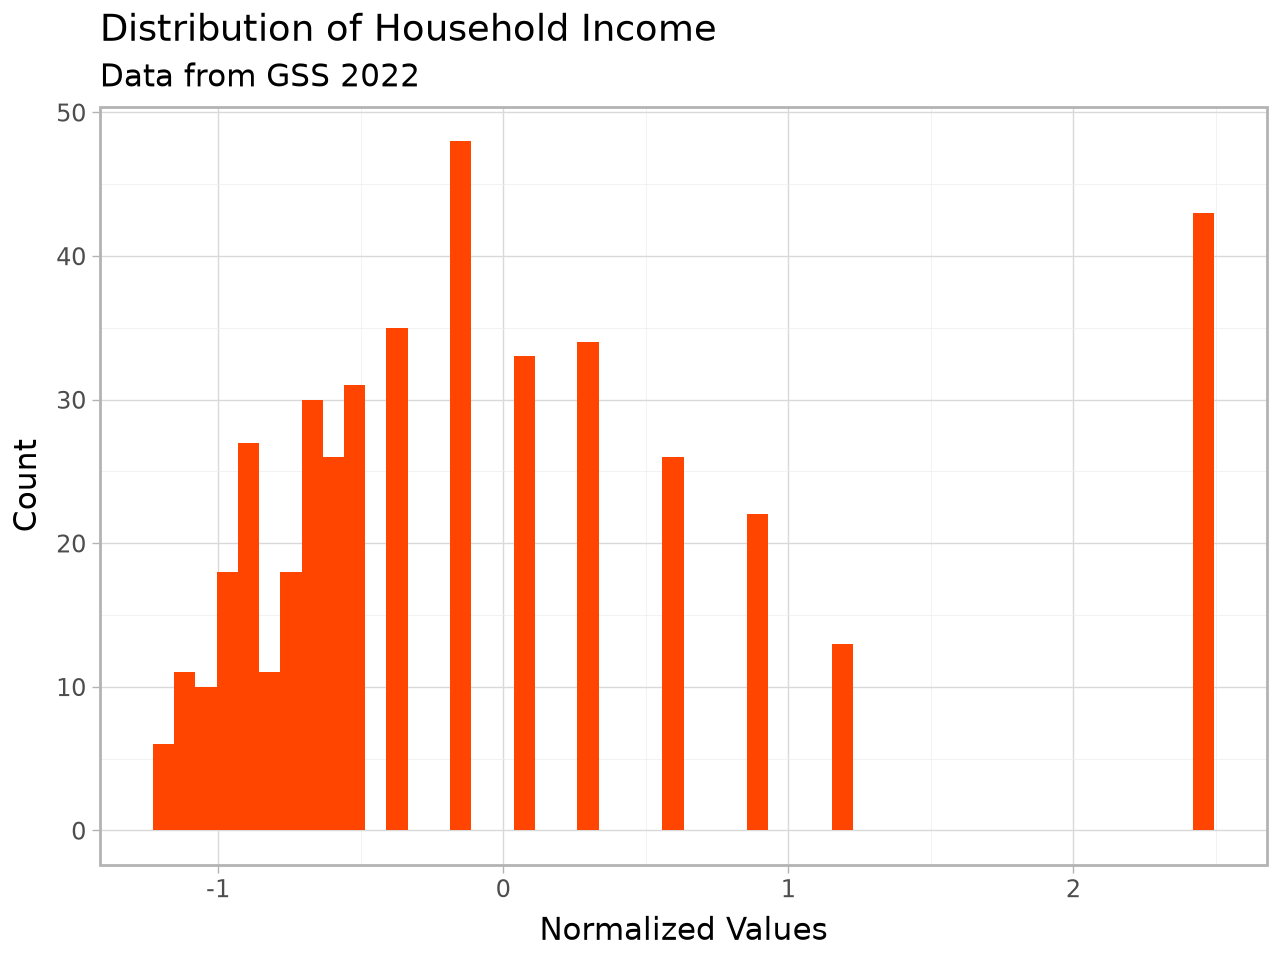

In [14]:
p = (
	p9.ggplot(df_large) +
	p9.geom_histogram(p9.aes(x='scaled_income'), bins=50, fill='orangered') +
	p9.theme_light() +
	p9.labs(x='Normalized Values', y='Count',
			title='Distribution of Household Income', subtitle='Data from GSS 2022')
)
p.save('hist_income.png', width=15, height=10.5, units='cm')
p

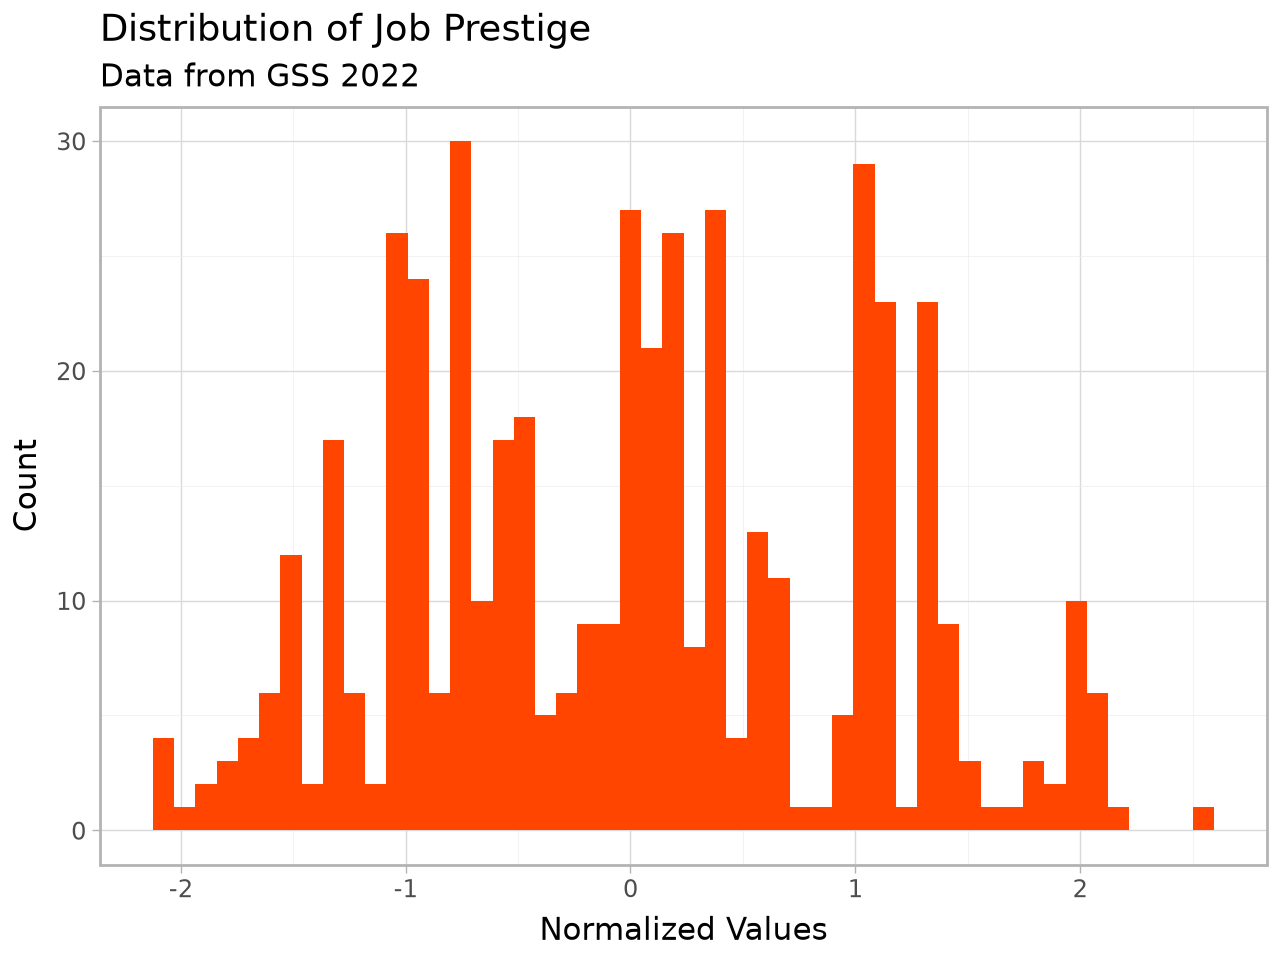

In [15]:
p = (
	p9.ggplot(df_large) +
	p9.geom_histogram(p9.aes(x='scaled_prestg'), bins=50, fill='orangered') +
	p9.theme_light() +
	p9.labs(x='Normalized Values', y='Count',
			title='Distribution of Job Prestige', subtitle='Data from GSS 2022')
)
p.save('hist_prestige.png', width=15, height=10.5, units='cm')
p

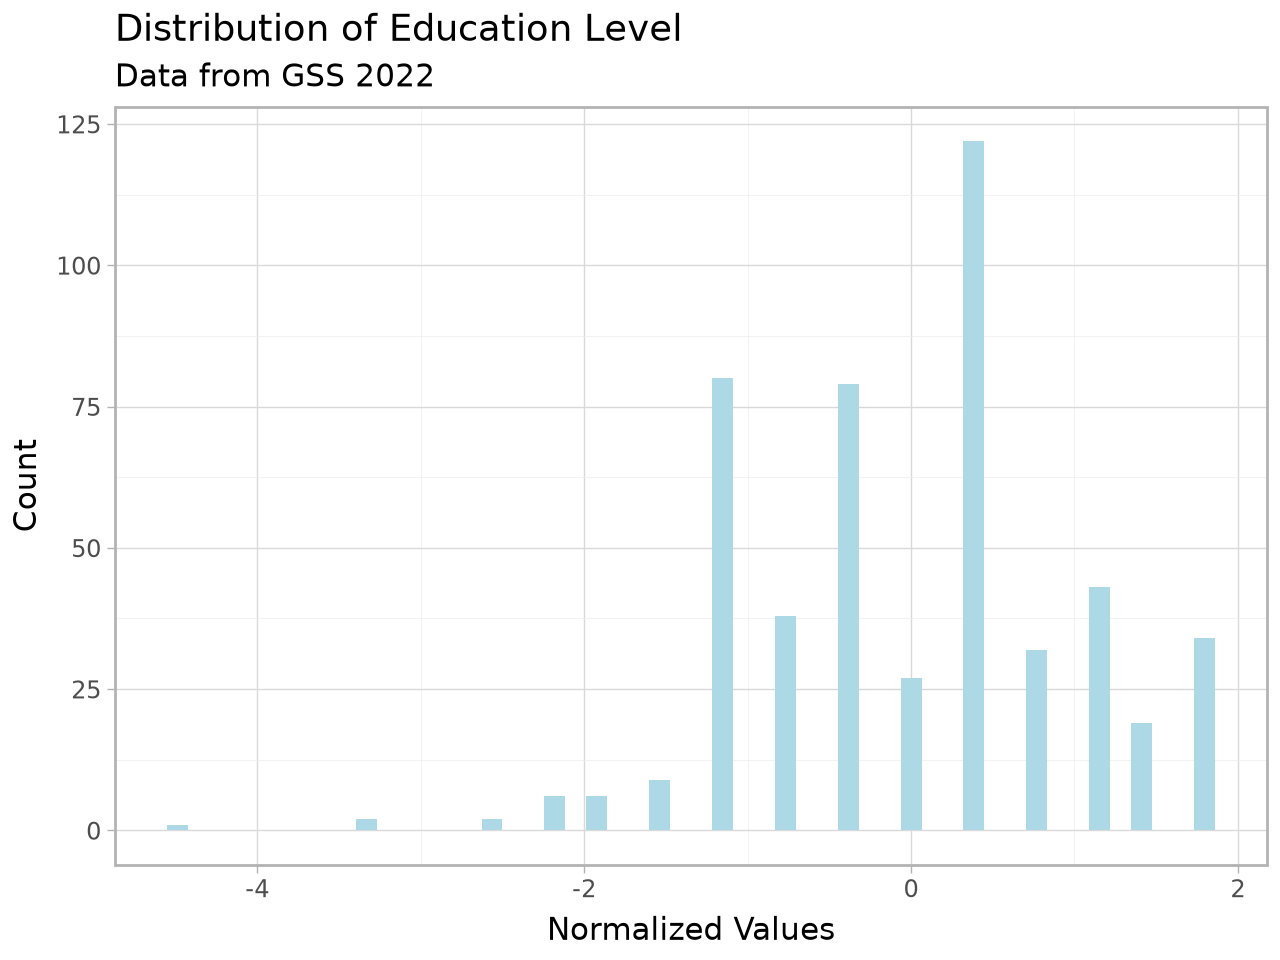

In [46]:
p = (
	p9.ggplot(df_large) +
	p9.geom_histogram(p9.aes(x='scaled_edu'), bins=50, fill='lightblue') +
	p9.theme_light() +
	p9.labs(x='Normalized Values', y='Count',
			title='Distribution of Education Level', subtitle='Data from GSS 2022')
)
p.save('hist_edu.png', width=15, height=10.5, units='cm')
p

## Calculate Skewness of each variable

Skewness > 0 is right-skewed (long right tail); < 0 is left-skewed.

In [51]:
print('Skewness of Income (scaled):',  skew(df_large['scaled_income']))

Skewness of Income (scaled): 1.1834859348425193


In [47]:
print('Skewness of Job Prestige (scaled):',  skew(df_large['scaled_prestg']))

Skewness of Job Prestige (scaled): 0.12701021197964552


In [49]:
print('Skewness of Education Level (scaled):',  skew(df_large['scaled_edu']))

Skewness of Education Level (scaled): -0.24999456414958643


## Calculate Kurtosis of each variable

`scipy.stats.kurtosis` with `fisher=False` gives Pearson kurtosis (same as R's `moments::kurtosis`). A normal distribution has kurtosis ≈ 3 (mesokurtic); > 3 is leptokurtic.

In [43]:
# fisher=False gives Pearson kurtosis — equivalent to R's moments::kurtosis()
print('Kurtosis of Income (scaled):',  kurtosis(df_large['scaled_income'], fisher=False))

Kurtosis of Income (scaled): 3.4482891831607017


In [52]:
print('Kurtosis of Job Prestige (scaled):',  kurtosis(df_large['scaled_prestg'], fisher=False))

Kurtosis of Job Prestige (scaled): 2.1356553724762186


In [53]:
print('Kurtosis of Education Level (scaled):',  kurtosis(df_large['scaled_edu'], fisher=False))

Kurtosis of Education Level (scaled): 3.3774297856734425


# Mean of each variable

In [55]:
print('Mean Income:', df['income_cont'].mean())

Mean Income: 87403.37001375516


In [56]:
print('Mean Education Level:', df['educ'].mean())

Mean Education Level: 15.026134800550206


In [60]:
print('Mean of Job Prestige:', df['prestg10'].mean())

Mean of Job Prestige: 48.099037138927095


# Variance of each variable

In [58]:
print('Variance of income:', df['income_cont'].var())

Variance of income: 5135962154.605325


In [59]:
print('Variance of income:', df_large['income_cont'].var())

Variance of income: 5171850225.2004


In [61]:
print('Variance of job prestige:', df['prestg10'].var())

Variance of job prestige: 183.61001284572623


In [62]:
print('Variance of education level:', df['educ'].var())

Variance of education level: 7.011712725605436
